# 

## Import

In [1]:
import json
import os
import random

import numpy as np
import torch
from torch.utils.data import DataLoader

In [2]:
print(f"PyTorch 版本: {torch.__version__}")
print(f"CUDA 可用: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch 版本: 2.13.0+cpu
CUDA 可用: False


## Configuration

In [ ]:
# 全部可選波段（參考用，共 8 種）
ALL_BANDS = ["Green", "Red", "NIR", "SWIR", "SCL", "NDVI", "NDWI", "LSWI"]

# 自定義要使用的波段 ── 從 ALL_BANDS 中選取，順序即為輸出通道順序
CHOSEN_BANDS = ["Green", "Red", "NIR", "SWIR"]

# split_mode 控制本次執行跑哪個切分方式：
#   "time"    → Case1：以「灌水日期」分割（2023 train/valid 7:3，2026 全部作 test）
#   "spatial" → Case2：以「區塊」分割（11 個區塊 7:2:2）
# 可用環境變數 SPLIT_MODE 覆寫，方便用 nbconvert --execute 分別批次跑兩個 case
# 而不用手動改這個 cell。
SPLIT_MODE = os.environ.get("SPLIT_MODE", "time")
assert SPLIT_MODE in ("time", "spatial"), f"SPLIT_MODE 必須是 'time' 或 'spatial'，收到：{SPLIT_MODE!r}"

_BASE_OUTPUT_DIR = r"C:\Users\cathyhsu\Desktop\Sentinal2-ModelA-Irrigation\model_output"
_CASE_DIR_NAME = {"time": "case1_time_split", "spatial": "case2_spatial_split"}[SPLIT_MODE]

CONFIG = {
    # ── Path ──────────────────────────────────────────────────────────────
    "xy_dir":               r"D:\嘉璯\S2全台資料_Xy對應",  # 切割成 11 區域後的資料夾
    "output_dir":           os.path.join(_BASE_OUTPUT_DIR, _CASE_DIR_NAME),
    # run_name 自動取 output_dir 最後一段，不需另外設定

    # ── Split ─────────────────────────────────────────────────────────────
    "split_mode":           SPLIT_MODE,
    "seed":                 42,
    "time_train_ratio":     0.7,          # Case1：2023 train/valid 日期比例 7:3
    "train_valid_years":    ("2023",),    # train/valid 日期的年份字首（Case1：2023 第 1、2 期作）
    "test_years":           ("2026",),    # test 日期的年份字首（Case1：2026 第 1 期作）
    "region_train_ratio":   0.6,          # Case2：11 個區塊 round(11*0.6)=7
    "region_val_ratio":     0.2,          # Case2：round(11*0.2)=2 → 7:2:2

    # ── Data ──────────────────────────────────────────────────────────────
    # Case1／Case2 的切割輸出各自獨立命名，避免共用固定資料夾名稱造成互相覆蓋
    "train_data_dir_name":  f"training_data_{SPLIT_MODE}",
    "valid_data_dir_name":  f"valid_data_{SPLIT_MODE}",
    "test_data_dir_name":   f"testing_data_{SPLIT_MODE}",
    "generate_patch":       False,         # False=沿用既有資料夾（缺資料夾才補切）；
                                            # Case1（time）已切好 train/valid/test，可直接沿用
    "chosen_bands":         CHOSEN_BANDS,
    "nodata_value":         999,
    "scl_num_classes":      12,           # Sentinel-2 SCL 固定 12 類
    "patch_size":           256,
    "stride_x":             256,          # train patch stride（= patch_size 為非重疊）
    "stride_y":             256,
    "keep_remainder":       False,
    "use_dynamic_stride_x": False,        # True=動態調整 stride_x，避免 patch 右側出現過多 nodata
    "stride_x_min":         64,           # 動態 stride 的最小值（use_dynamic_stride_x=True 時有效）
    "filter_all_nodata":    True,
    "filter_no_water":      False,
    "cloud_rate_threshold": None,         # None=不篩選；e.g. 0.3=剔除雲量 >30% 的 patch

    # ── Loader ────────────────────────────────────────────────────────────
    "batch_size":           4,
    "num_workers":          0,            # Windows 建議設 0，Linux 可設 2/4
    "pin_memory":           torch.cuda.is_available(),

    # ── Model ─────────────────────────────────────────────────────────────
    "encoder_name":         "resnet34",

    # ── Loss ──────────────────────────────────────────────────────────────
    "pos_weight":           1.0,
    "bce_weight":           0.5,
    "dice_weight":          0.5,
    "scl_mask":             False,         # True=遮蔽 SCL∈{3,8,9}（雲影/中機率雲/高機率雲）的 pixel

    # ── Train ─────────────────────────────────────────────────────────────
    # EPOCHS/PATIENCE 環境變數可覆寫，方便先用極小值跑一次 nbconvert 驗證整條
    # pipeline 沒有錯誤，確認無誤後再用預設值（100/10）跑正式訓練。
    "epochs":               int(os.environ.get("EPOCHS", 100)),
    "patience":             int(os.environ.get("PATIENCE", 10)),
    "lr":                   1e-4,
    "weight_decay":         1e-5,
    "device":               "cuda" if torch.cuda.is_available() else "cpu",
}

In [4]:
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(CONFIG["seed"])
os.makedirs(CONFIG["output_dir"], exist_ok=True)

cfg_save = {k: v for k, v in CONFIG.items() if not isinstance(v, bool)}
with open(os.path.join(CONFIG["output_dir"], "config.json"), "w", encoding="utf-8") as f:
    json.dump(cfg_save, f, indent=4, ensure_ascii=False)
print("✓ config.json 已寫入")
print(f"  split_mode : {CONFIG['split_mode']}")
print(f"  output_dir : {CONFIG['output_dir']}")

✓ config.json 已寫入
  split_mode : time
  output_dir : C:\Users\cathyhsu\Desktop\Geospatial predictive modeling\2023_1&2\model_output\case1_time_split


## Train-Valid-Test Split

### 使用資料範圍

#### Case1. 以「灌水日期」分割
1. train/valid: 2023 第 1 期作和第 2 期作，共 21 個日期的灌水圖，分成 7:3 。
2. test: 2026 第 1 期作，共 12 個日期的灌水圖。

#### Case2. 以「區塊」分割
共有 11 個區塊，命名為 N1, N2, EN, E1, E2, E3, W1, W2, W3, W4, W5，分成 6:2:2 。


In [5]:
from src.preprocessing.Preprocess import train_valid_test_split_by_year

# Case1（時間切分）與 Case2（空間切分）共用下游變數名稱：
#   train_dates / val_dates / test_dates   → 要處理的日期
#   train_regions / val_regions / test_regions → 要篩選的區塊（None = 不篩選，全部區塊）
train_regions = val_regions = test_regions = None

if CONFIG["split_mode"] == "time":
    # 1. 日期切分（Case1：以「灌水日期」分割）
    train_dates, val_dates, test_dates, train_files, val_files, test_files = train_valid_test_split_by_year(
        base_dir=CONFIG["xy_dir"],
        train_ratio=CONFIG["time_train_ratio"],
        seed=CONFIG["seed"],
        train_valid_years=CONFIG["train_valid_years"],
        test_years=CONFIG["test_years"],
    )
    print(f"✓ 日期切分  train={train_dates}  val={val_dates}  test={test_dates}")
    print(f"✓ 檔案切分  train_files={len(train_files)} 個  val_files={len(val_files)} 個  test_files={len(test_files)} 個")
    print(f"  train_files 範例: {train_files[:5]}")
    print(f"  val_files   範例: {val_files[:5]}")
    print(f"  test_files  範例: {test_files[:5]}")
else:
    print(f"split_mode='{CONFIG['split_mode']}'，略過時間切分（見下一個 cell 的空間切分）")

FileNotFoundError: 找不到 y/ 資料夾：D:\研究一所\嘉璯\S2全台資料_Xy對應\y

In [ ]:
from pathlib import Path
from src.preprocessing.Preprocess import split_regions_train_valid_test

if CONFIG["split_mode"] == "spatial":
    # 2. 區塊切分（Case2：以「區塊」分割，train/valid/test 共用「全部日期」，
    #    只依區塊歸屬做切分，避免同一區塊同時出現在不同 split 造成空間洩漏）
    train_regions, val_regions, test_regions, train_files, val_files, test_files = split_regions_train_valid_test(
        base_dir=CONFIG["xy_dir"],
        train_ratio=CONFIG["region_train_ratio"],
        val_ratio=CONFIG["region_val_ratio"],
        seed=CONFIG["seed"],
    )
    train_dates = val_dates = test_dates = sorted(
        p.name for p in (Path(CONFIG["xy_dir"]) / "y").iterdir() if p.is_dir()
    )
    print(f"✓ 區塊切分  train={train_regions}  val={val_regions}  test={test_regions}")
    print(f"✓ 共用日期數（train=val=test 皆為全部日期，只依區塊篩選）：{len(train_dates)}")
    print(f"✓ 檔案切分  train_files={len(train_files)} 個  val_files={len(val_files)} 個  test_files={len(test_files)} 個")
    print(f"  train_files 範例: {train_files[:5]}")
    print(f"  val_files   範例: {val_files[:5]}")
    print(f"  test_files  範例: {test_files[:5]}")
else:
    print(f"split_mode='{CONFIG['split_mode']}'，略過空間切分")

## Normalization

In [ ]:
from src.preprocessing.Preprocess import compute_band_percentiles, compute_band_mean_std

# 標準化參數（只用 train_dates / train_regions；來源為切割成 11 區域後的
# "xy對應" 資料夾，只計算前 4 個原始波段 Green/Red/NIR/SWIR）
#
# Step 2（模型規劃.md.md）：先用 train 統計出的 1st~99th 百分位數做離群值裁切，
# 取代寫死的 (0, 10000)，clip 邊界與 mean/std 皆只能用 train 算，避免 val/test 洩漏。
_RAW_BANDS = ["Green", "Red", "NIR", "SWIR"]

clip_min, clip_max = compute_band_percentiles(
    base_dir=CONFIG["xy_dir"],
    dates=train_dates,
    regions=train_regions,
    numeric_bands=_RAW_BANDS,
    lower=1.0,
    upper=99.0,
    nodata_value=CONFIG["nodata_value"],
)
print(f"✓ 百分位裁切邊界  clip_min={clip_min}  clip_max={clip_max}")

mean, std = compute_band_mean_std(
    base_dir=CONFIG["xy_dir"],
    dates=train_dates,
    regions=train_regions,
    numeric_bands=_RAW_BANDS,
    nodata_value=CONFIG["nodata_value"],
    clip_min=clip_min,
    clip_max=clip_max,
)
print(f"✓ 標準化參數  mean={mean}  std={std}")

## Patch 切割

In [ ]:
from src.preprocessing.data_cut import cut_xy_patches

# 切割 patch（train / valid / test），輸出資料夾名稱依 split_mode 各自獨立
# （train_data_dir_name 等，見 CONFIG），避免 Case1／Case2 共用固定資料夾名稱互相覆蓋。
# 產生的資料夾實際位置在 xy_dir 的上一層（xy_dir.parent），而非 CWD 相對路徑，
# 因此一律使用 cut_xy_patches() 的回傳絕對路徑，不再假設 "training_data" 這種
# CWD 相對字串一定存在。
def _get_or_cut(mode, dates, regions, dir_name):
    xy_parent = os.path.dirname(CONFIG["xy_dir"])
    existing = os.path.join(xy_parent, dir_name)
    if not CONFIG["generate_patch"] and os.path.exists(existing):
        return existing
    return cut_xy_patches(
        xy_dir=CONFIG["xy_dir"], dates=dates, regions=regions, mode=mode,
        out_dir_name=dir_name,
        patch_size=CONFIG["patch_size"],
        stride_x=CONFIG["stride_x"],
        stride_y=CONFIG["stride_y"],
        keep_remainder=CONFIG["keep_remainder"] if mode == "train" else True,
        use_dynamic_stride_x=CONFIG["use_dynamic_stride_x"] if mode == "train" else False,
        stride_x_min=CONFIG["stride_x_min"],
        filter_all_nodata=CONFIG["filter_all_nodata"] if mode == "train" else False,
        filter_no_water=CONFIG["filter_no_water"] if mode == "train" else False,
        cloud_rate_threshold=CONFIG["cloud_rate_threshold"] if mode == "train" else None,
        nodata_value=CONFIG["nodata_value"],
    )

train_dir = _get_or_cut("train", train_dates, train_regions, CONFIG["train_data_dir_name"])
val_dir   = _get_or_cut("valid", val_dates,   val_regions,   CONFIG["valid_data_dir_name"])
test_dir  = _get_or_cut("test",  test_dates,  test_regions,  CONFIG["test_data_dir_name"])

print(f"✓ Patch 切割完成  train_dir={train_dir}  val_dir={val_dir}  test_dir={test_dir}")

## Dataset

In [ ]:
from src.dataset.Dataset import OneSliceDataset

# Dataset（讀取「Patch 切割」cell 已切好的 patch，不再重新觸發切割）
train_dataset = OneSliceDataset(
    data_dir=train_dir, dates=train_dates,
    features=CONFIG["chosen_bands"],
    mean=mean, std=std, clip_min=clip_min, clip_max=clip_max,
    scl_num_classes=CONFIG["scl_num_classes"],
    nodata_value=CONFIG["nodata_value"],
)
val_dataset = OneSliceDataset(
    data_dir=val_dir, dates=val_dates,
    features=CONFIG["chosen_bands"],
    mean=mean, std=std, clip_min=clip_min, clip_max=clip_max,
    scl_num_classes=CONFIG["scl_num_classes"],
    nodata_value=CONFIG["nodata_value"],
)
test_dataset = OneSliceDataset(
    data_dir=test_dir, dates=test_dates,
    features=CONFIG["chosen_bands"],
    mean=mean, std=std, clip_min=clip_min, clip_max=clip_max,
    scl_num_classes=CONFIG["scl_num_classes"],
    nodata_value=CONFIG["nodata_value"],
)
print(f"✓ Dataset  train={len(train_dataset)}  val={len(val_dataset)}  test={len(test_dataset)}")
print(f"  每個 patch 通道數 = {train_dataset.num_channels}")

print(f"\nTrain: {len(train_dataset)} patches")
print(f"Valid: {len(val_dataset)} patches")
print(f"Test:  {len(test_dataset)} patches")

X_sample, y_sample, _ = train_dataset[0]
print(f"\nX shape: {tuple(X_sample.shape)}  dtype={X_sample.dtype}")
print(f"y shape: {tuple(y_sample.shape)}  dtype={y_sample.dtype}")

In [ ]:
from src.preprocessing.data_cut import reconstruct_y_patches

def _reconstruct_all_regions(data_dir, dates):
    for date in dates:
        y_date_dir = os.path.join(data_dir, "y", date)
        if not os.path.isdir(y_date_dir):
            continue
        for region in sorted(os.listdir(y_date_dir)):
            region_dir = os.path.join(y_date_dir, region)
            if os.path.isdir(region_dir):
                reconstruct_y_patches(date_dir=region_dir)

print("── testing_data 重建（逐區域）──")
_reconstruct_all_regions(test_dir, test_dates)

## EDA

In [ ]:
import io
from contextlib import redirect_stdout
from src.dataset.eda import count_zero_nodata_patches

# EDA：查看各 split 切割結果，結果暫存於 eda_text（在 TensorBoard Setup 寫入）
eda_text = ""
for label, dataset, dates in [
    ("Train", train_dataset, train_dates),
    ("Valid", val_dataset, val_dates),
    ("Test",  test_dataset, test_dates),
]:
    header = (
        f"\n══════════════════════════════════════════════\n"
        f"  {label} 全 0 / 全 nodata patch 統計\n"
        f"══════════════════════════════════════════════\n"
    )
    print(header, end="")
    buf = io.StringIO()
    with redirect_stdout(buf):
        count_zero_nodata_patches(data_dir=str(dataset.data_dir), dates=dates)
    result = buf.getvalue()
    print(result)
    eda_text += header + result + "\n"


══════════════════════════════════════════════
  Train 全 0 / 全 nodata patch 統計
══════════════════════════════════════════════
    date  total  all_nodata  all_zero  have_one
20230130   3179           0      2024      1155
20230204   3179           0      2020      1159
20230209   3179           0      1957      1222
20230219   3179           0      1773      1406
20230301   3179           0      1746      1433


══════════════════════════════════════════════
  Valid 全 0 / 全 nodata patch 統計
══════════════════════════════════════════════
    date  total  all_nodata  all_zero  have_one
20230306   5800        2385      1862      1553
20230311   5800        2385      1861      1554


══════════════════════════════════════════════
  Test 全 0 / 全 nodata patch 統計
══════════════════════════════════════════════
    date  total  all_nodata  all_zero  have_one
20230316   5800        2385      1849      1566



══════════════════════════════════════════════
  Train patch 灌水率與雲量遮蔽率
══════════════════════════════════════════════
          water_ratio_%  scl_cloud_ratio_%
date                                      
20230130           5.19               7.20
20230204           5.26              65.17
20230209           6.56              33.22
20230219           9.28              28.76
20230301          10.70              10.68
[已儲存] C:\Users\cathyhsu\Desktop\Geospatial predictive modeling\2023_1\model_output\base_model\eda_irrigation_cloud_distribution.png


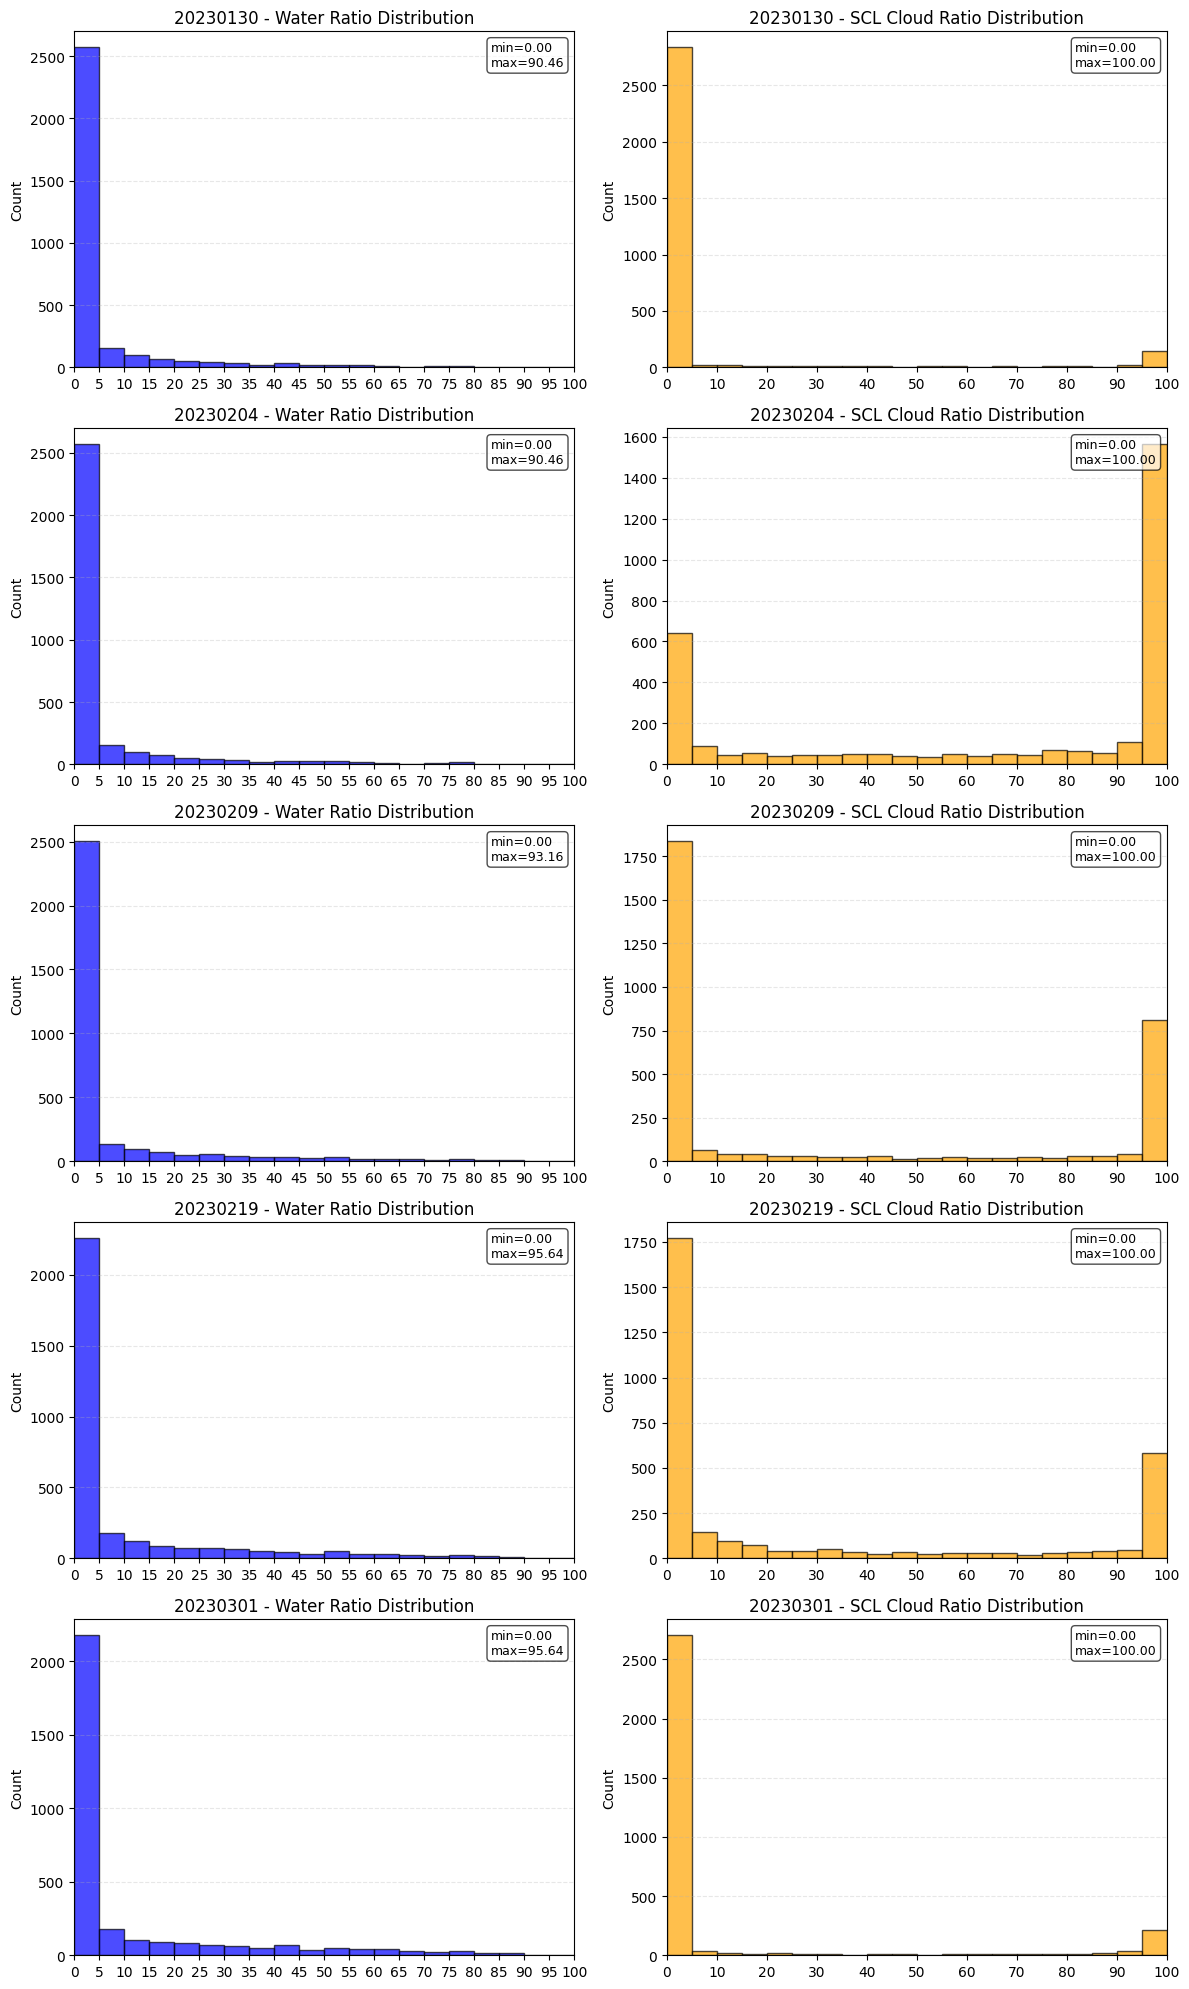

In [ ]:
from src.dataset.eda import compute_irrigation_cloud_cover_rate, plot_irrigation_cloud_distribution

# EDA：Train patch 灌水率與雲量遮蔽率
header_irr = (
    "══════════════════════════════════════════════\n"
    "  Train patch 灌水率與雲量遮蔽率\n"
    "══════════════════════════════════════════════\n"
)
print(header_irr, end="")

df = compute_irrigation_cloud_cover_rate(
    data_dir=str(train_dataset.data_dir),
    dates=train_dates,
)
irr_result = df.groupby("date")[["water_ratio_%", "scl_cloud_ratio_%"]].mean().round(2).to_string()
print(irr_result)
plot_irrigation_cloud_distribution(
    df,
    save_path=os.path.join(CONFIG["output_dir"], "eda_irrigation_cloud_distribution.png"),
)

eda_text += "\n" + header_irr + irr_result + "\n"

## Dataloader

In [ ]:
# 4. DataLoader
# test_loader 與 val_loader 必須 shuffle=False，
# 確保 batch 順序與 dataset.samples 一致（evaluating_all 依此對應 patch 檔名）
train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=True,
    num_workers=CONFIG["num_workers"],
    pin_memory=CONFIG["pin_memory"],
)
val_loader = DataLoader(
    val_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    num_workers=CONFIG["num_workers"],
    pin_memory=CONFIG["pin_memory"],
)
test_loader = DataLoader(
    test_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    num_workers=CONFIG["num_workers"],
    pin_memory=CONFIG["pin_memory"],
)
print(f"✓ DataLoader  train={len(train_loader)} batches  val={len(val_loader)} batches  test={len(test_loader)} batches")

✓ DataLoader  train=3974 batches  val=2900 batches  test=1450 batches


## Model

In [ ]:
from src.model.Model import MaskedDiceBCELoss, build_model

# 5. 建立模型、Loss、Optimizer
device = CONFIG["device"]

model = build_model(
    in_channels=train_dataset.num_channels,
    encoder_name=CONFIG["encoder_name"],
).to(device)

criterion = MaskedDiceBCELoss(
    ignore_index=CONFIG["nodata_value"],
    bce_weight=CONFIG["bce_weight"],
    dice_weight=CONFIG["dice_weight"],
    pos_weight=CONFIG["pos_weight"],
    use_scl_mask=CONFIG["scl_mask"],
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=CONFIG["lr"],
    weight_decay=CONFIG["weight_decay"],
)

print(f"✓ 模型建立完成  device={device}  in_channels={train_dataset.num_channels}")

✓ 模型建立完成  device=cuda  in_channels=5


## TensorBoard Setup

In [ ]:
from tensorboardX import SummaryWriter
import shutil

# run_name 自動取 output_dir 最後一段（e.g. "base_model"）
run_name   = os.path.basename(CONFIG["output_dir"])
tb_root    = os.path.join(os.path.dirname(CONFIG["output_dir"]), "tb_logs")
tb_log_dir = os.path.join(tb_root, run_name)

# 若此 run 已有舊資料則先清空（只清自己這個 run，不影響其他 run）
if os.path.exists(tb_log_dir):
    shutil.rmtree(tb_log_dir)
    print(f"  舊資料已清除：{tb_log_dir}")
os.makedirs(tb_log_dir)

writer = SummaryWriter(log_dir=tb_log_dir)

# TEXT tab：EDA 結果（eda_text 由 eda-nodata 儲存格產生）
writer.add_text("EDA", "```\n" + eda_text + "```", global_step=0)

print(f"✓ TensorBoard writer 已建立")
print(f"✓ EDA 結果已寫入 TensorBoard TEXT tab")
print(f"  run_name : {run_name}")
print(f"  log_dir  : {tb_log_dir}")
print(f"\n  開啟所有 runs：")
print(f"  c:\\Python311\\python.exe -m tensorboard.main --logdir \"{tb_root}\"")

  舊資料已清除：C:\Users\cathyhsu\Desktop\Geospatial predictive modeling\2023_1\model_output\tb_logs\base_model
✓ TensorBoard writer 已建立
✓ EDA 結果已寫入 TensorBoard TEXT tab
  run_name : base_model
  log_dir  : C:\Users\cathyhsu\Desktop\Geospatial predictive modeling\2023_1\model_output\tb_logs\base_model

  開啟所有 runs：
  c:\Python311\python.exe -m tensorboard.main --logdir "C:\Users\cathyhsu\Desktop\Geospatial predictive modeling\2023_1\model_output\tb_logs"


## Training

In [15]:
from src.training.TrainingFuncs import training

# 6. 訓練（含 early stopping 與 checkpoint）
history = training(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    config=CONFIG,
    device=device,
    writer=writer,
)

[Epoch 001/100] loss 0.4334/0.4678  f1 0.6594/0.7478
  ✓ 已儲存最佳模型（val_loss=0.4678）


[Epoch 002/100] loss 0.3985/0.4740  f1 0.7028/0.7469
  ⚠ 未改善 (1/10)


[Epoch 003/100] loss 0.3888/0.4607  f1 0.7125/0.7561
  ✓ 已儲存最佳模型（val_loss=0.4607）


[Epoch 004/100] loss 0.3805/0.4665  f1 0.7179/0.7524
  ⚠ 未改善 (1/10)


[Epoch 005/100] loss 0.3721/0.4589  f1 0.7237/0.7622
  ✓ 已儲存最佳模型（val_loss=0.4589）


...

[Epoch 012/100] loss 0.3410/0.4474  f1 0.7575/0.7727
  ✓ 已儲存最佳模型（val_loss=0.4474）


[Epoch 013/100] loss 0.3365/0.4575  f1 0.7614/0.7862
  ⚠ 未改善 (1/10)


[Epoch 014/100] loss 0.3340/0.4569  f1 0.7612/0.7700
  ⚠ 未改善 (2/10)


[Epoch 015/100] loss 0.3257/0.4768  f1 0.7665/0.7880
  ⚠ 未改善 (3/10)


KeyboardInterrupt: 

## Testing

In [ ]:
from src.training.TrainingFuncs import evaluating_all

# 7. 載入最佳模型，在測試集評估並存結果
checkpoint = torch.load(CONFIG['output_dir'] + "/best_model.pt", map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])

test_metrics_all = evaluating_all(
    model, test_loader, device,
    ignore_index=CONFIG["nodata_value"],
    dataset=test_dataset,
    save_dir=CONFIG["output_dir"],
)
print(f"✅ evaluating_all 完成：{test_metrics_all}")

# HPARAMS tab：用 torch.utils.tensorboard 寫入（與 TensorBoard 2.17.1 相容）
# cloud_rate_threshold 為 None 時以 -1.0 代表「不篩選」
_hparams = {
    "chosen_bands":         str(CONFIG["chosen_bands"]),
    "patch_size":           int(CONFIG["patch_size"]),
    "use_dynamic_stride_x": str(CONFIG["use_dynamic_stride_x"]),
    "filter_all_nodata":    str(CONFIG["filter_all_nodata"]),
    "filter_no_water":      str(CONFIG["filter_no_water"]),
    "cloud_rate_threshold": float(CONFIG["cloud_rate_threshold"]) if CONFIG["cloud_rate_threshold"] is not None else -1.0,
}
_metrics = {
    "best_val_loss":  float(history["best_val_loss"]),
    "best_val_acc":   float(max(history["val_acc"])),
    "best_val_f1":    float(max(history["val_f1"])),
    "test_acc":       float(test_metrics_all["accuracy"]),
    "test_precision": float(test_metrics_all["precision"]),
    "test_recall":    float(test_metrics_all["recall"]),
    "test_f1":        float(test_metrics_all["f1"]),
    "test_IoU":       float(test_metrics_all["iou"]),
}
from torch.utils.tensorboard import SummaryWriter as _TorchSW
from torch.utils.tensorboard.writer import hparams as _make_hparam_proto

_hw = _TorchSW(log_dir=tb_log_dir)
exp, ssi, sei = _make_hparam_proto(_hparams, _metrics)
_hw.file_writer.add_summary(exp)
_hw.file_writer.add_summary(ssi)
_hw.file_writer.add_summary(sei)
for k, v in _metrics.items():
    _hw.add_scalar(k, v, global_step=0)

_hw.close()
print("✓ HParams 已寫入 TensorBoard")

C:\Users\cathyhsu\AppData\Local\Temp\ipykernel_23524\2403804473.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(CONFIG['output_dir'] + "/best_mod


── 重建完整預測圖 ──
  ✓ 已儲存：C:\Users\cathyhsu\Desktop\Geospatial predictive modeling\data\S2訓練資料\model_output\base_model_dycut\test_pred\20230316\result.npy  shape=(2723, 3919)  dtype=float32
✅ evaluating_all 完成：{'accuracy': np.float64(0.859160251067306), 'precision': np.float64(0.7013273904732181), 'recall': np.float64(0.6589372113481416), 'f1': np.float64(0.6794717943872247), 'iou': np.float64(0.5145454610505075), 'confusion_matrix': [[683904, 61247], [74439, 143817]]}
✓ HParams 已寫入 TensorBoard


## 預測結果視覺化（TP/TN/FP/FN map）

In [ ]:
from src.visualization.myplot import plot_confusion_map
from PIL import Image
import torchvision.transforms.functional as TF

# ── 執行比對（逐日期、逐區域）──
for date in test_dates:
    y_date_dir = os.path.join(test_dir, "y", date)
    if not os.path.isdir(y_date_dir):
        continue
    regions = sorted(
        r for r in os.listdir(y_date_dir)
        if os.path.isdir(os.path.join(y_date_dir, r))
    )
    for region in regions:
        PRED_PATH = os.path.join(CONFIG['output_dir'], "test_pred", date, region, "result.npy")
        GT_PATH   = os.path.join(test_dir, "y", date, region, "result.npy")
        SAVE_PATH = os.path.join(CONFIG['output_dir'], f"confusion_map_{date}_{region}.png")

        counts = plot_confusion_map(
            pred_path=PRED_PATH,
            gt_path=GT_PATH,
            ignore_index=CONFIG['nodata_value'],
            save_path=SAVE_PATH,
            title=f"Confusion Map for {date}/{region}",
        )
        print(counts)

        # TensorBoard：寫入 confusion map 圖片（IMAGES tab）
        img = Image.open(SAVE_PATH).convert("RGB")
        img_tensor = TF.to_tensor(img)   # (3, H, W) float [0, 1]
        writer.add_image(f"Test/confusion_map_{date}_{region}", img_tensor, global_step=0)
        print(f"✓ Confusion map 已寫入 TensorBoard（{date}/{region}）")

In [ ]:
writer.close()
print("✓ TensorBoard writer 已關閉")
print(f"\n開啟 TensorBoard（顯示所有 runs）：")
print(f"  c:\\Python311\\python.exe -m tensorboard.main --logdir \"{tb_root}\"")
print(f"  → 在瀏覽器開啟 http://localhost:6006")

✓ TensorBoard writer 已關閉

開啟 TensorBoard（顯示所有 runs）：
  c:\Python311\python.exe -m tensorboard.main --logdir "C:\Users\cathyhsu\Desktop\Geospatial predictive modeling\data\S2訓練資料\model_output\tb_logs"
  → 在瀏覽器開啟 http://localhost:6006
